In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
import os
import glob
from dotenv import load_dotenv

sys.path.append(os.path.dirname(os.path.abspath('.')))

from decrypt import (
    gen_master_key, 
    decrypt_patient_file,
    NUM_OF_PATIENTS
)

load_dotenv()

plt.style.use('default')
sns.set_palette("husl")

security_key = os.getenv('SECURITY_KEY')

data_dir = "../data/blood_pressure"
print(f"\nReading {NUM_OF_PATIENTS} patients")



Reading 10 patients


In [34]:
def decrypt_all_patients_to_dataframes():
    """
    Decrypt all patient data and convert to pandas DataFrames.
    Uses imported decryption functions from decrypt.py
    """
    print("Starting decryption process...")
    
    # Get the security key
    security_key_str = os.getenv('SECURITY_KEY')
    if not security_key_str:
        print("SECURITY_KEY not found in .env file!")
        return {}
    
    # Generate master key using function from decrypt.py
    master_key = gen_master_key(security_key_str)
    patient_dataframes = {}
    
    # Process patients 01 through NUM_OF_PATIENTS
    for patient_num in range(1, NUM_OF_PATIENTS + 1):
        patient_id = f'patient{patient_num:02d}'
        patient_dir = f'../data/blood_pressure/{patient_id}'
        
        print(f'Processing {patient_id}...')
        
        # Check if directory exists
        if not os.path.exists(patient_dir):
            print(f'Directory {patient_dir} not found')
            continue
        
        # Get all blood pressure files for this patient
        blood_pressure_files = glob.glob(f'{patient_dir}/blood_pressure_*.json.enc.ttl')
        blood_pressure_files.sort()
        
        patient_observations = []
        
        for file_path in blood_pressure_files:
            filename = os.path.basename(file_path)
            
            observation = decrypt_patient_file(master_key, patient_dir, filename)
            
            if observation:
                patient_observations.append(observation)
        
        if patient_observations:
            # Convert list of dictionaries to DataFrame 
            df = pd.DataFrame(patient_observations)
            
            # Convert timestamp to datetime
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            
            # Convert columns data to numeric
            numeric_columns = ['systolic', 'diastolic', 'heart_rate']
            for col in numeric_columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Sort by timestamp
            df = df.sort_values('timestamp').reset_index(drop=True)
            
            # Add patient_id column for reference
            df['patient_id'] = patient_id
            
            patient_dataframes[patient_id] = df
            print(f'Created DataFrame for {patient_id}: {len(df)} observations')
        else:
            print(f'No data found for {patient_id}')
    
    print(f"\nSuccessfully created {len(patient_dataframes)} DataFrames")
    return patient_dataframes

# Execute the function
patient_dfs = decrypt_all_patients_to_dataframes()


Starting decryption process...
Processing patient01...
Created DataFrame for patient01: 20 observations
Processing patient02...
Created DataFrame for patient02: 20 observations
Processing patient03...
Created DataFrame for patient03: 20 observations
Processing patient04...
Created DataFrame for patient04: 20 observations
Processing patient05...
Created DataFrame for patient05: 20 observations
Processing patient06...
Created DataFrame for patient06: 20 observations
Processing patient07...
Created DataFrame for patient07: 20 observations
Processing patient08...
Created DataFrame for patient08: 20 observations
Processing patient09...
Created DataFrame for patient09: 20 observations
Processing patient10...
Created DataFrame for patient10: 20 observations

Successfully created 10 DataFrames


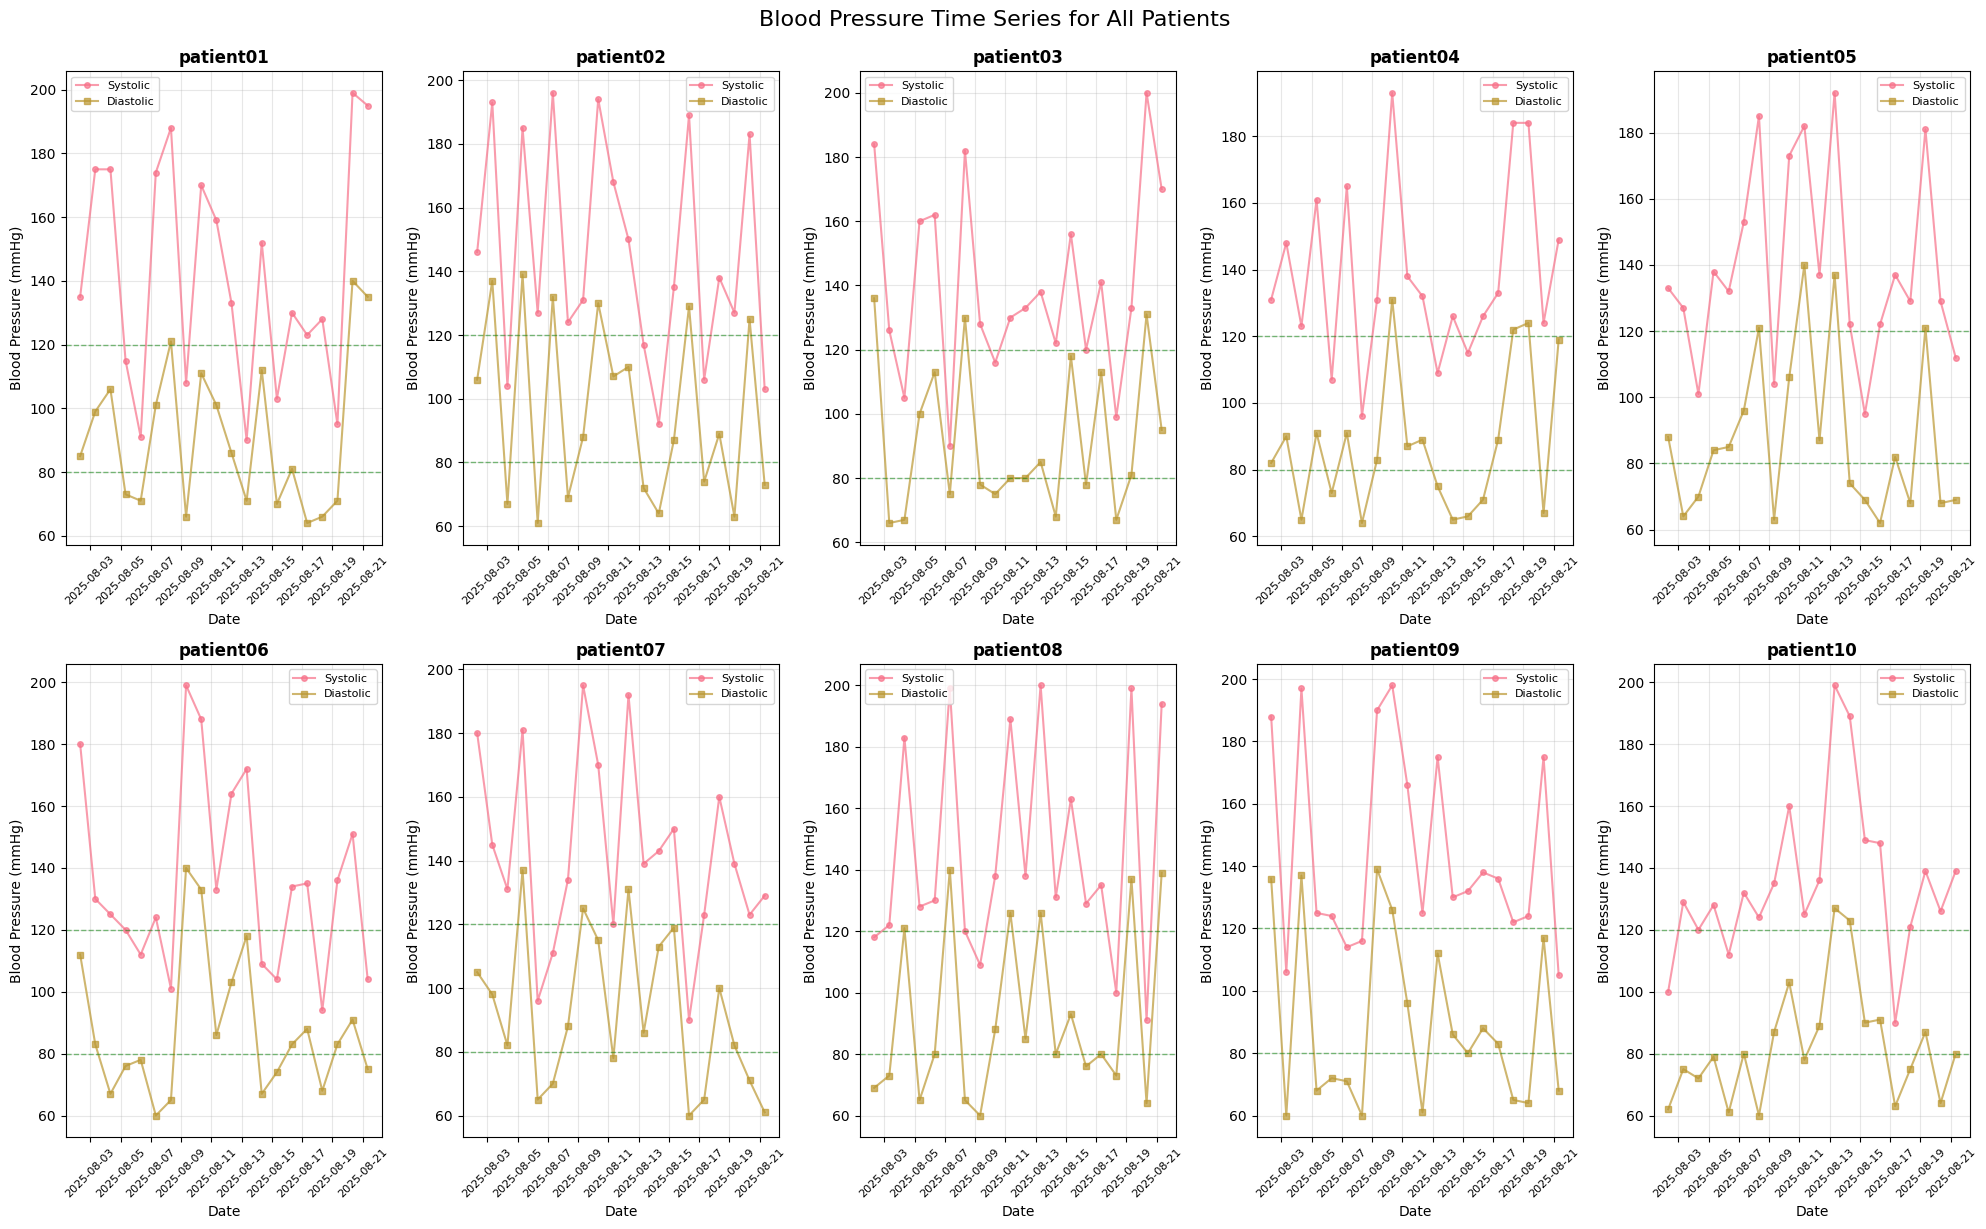

In [35]:
# Create visualization functions
def create_patient_visualizations(patient_dfs):
    """Create comprehensive visualizations for patient data analysis"""
    
    # Set up the plotting parameters
    plt.rcParams['figure.figsize'] = (15, 10)
    
    # Time series plot for each patient
    fig, axes = plt.subplots(2, 5, figsize=(20, 12))
    axes = axes.flatten()
    
    for i, (patient_id, df) in enumerate(patient_dfs.items()):
        ax = axes[i]
        
        # Plot systolic and diastolic over time
        ax.plot(df['timestamp'], df['systolic'], 'o-', label='Systolic', alpha=0.7, markersize=4)
        ax.plot(df['timestamp'], df['diastolic'], 's-', label='Diastolic', alpha=0.7, markersize=4)
        
        ax.set_title(f'{patient_id}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Blood Pressure (mmHg)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        # Add reference lines for normal BP
        ax.axhline(y=120, color='green', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=80, color='green', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.suptitle('Blood Pressure Time Series for All Patients', fontsize=16, y=1.02)
    plt.show()


# Create visualizations
create_patient_visualizations(patient_dfs)


In [36]:
def generate_patient_statistics(patient_dfs, export_summaries=True, export_format='json'):
    """Generate comprehensive statistics for each patient DataFrame and export to JSON files"""
    
    import json
    
    # Create export directory for summaries
    summary_dir = '../data/summary'
    if export_summaries:
        os.makedirs(summary_dir, exist_ok=True)
    
    # Create a summary statistics DataFrame
    summary_stats = []
    
    for patient_id, df in patient_dfs.items():
        # Create structured data for JSON export
        patient_json_data = {
            "patient_id": patient_id
        }
        
        # Add descriptive statistics to JSON structure
        descriptive_stats = {}
        numeric_cols = ['systolic', 'diastolic', 'heart_rate']
        
        for col in numeric_cols:
            if col in df.columns:
                values = df[col].dropna()
                if len(values) > 0:
                    col_stats = {
                        'count': int(len(values)),
                        'mean': round(float(values.mean()), 2),
                        'median': round(float(values.median()), 2),
                        'std': round(float(values.std()), 2),
                        'min': round(float(values.min()), 2),
                        'max': round(float(values.max()), 2),
                        'range': round(float(values.max() - values.min()), 2),
                        'percentile_25': round(float(values.quantile(0.25)), 2),
                        'percentile_75': round(float(values.quantile(0.75)), 2)
                    }
                    descriptive_stats[col] = col_stats
        
        patient_json_data['descriptive_statistics'] = descriptive_stats
        
        # Additional statistics for DataFrame
        patient_summary = {'patient_id': patient_id}
        for col in numeric_cols:
            if col in df.columns:
                values = df[col].dropna()
                if len(values) > 0:
                    patient_summary.update({
                        f'{col}_mean': values.mean(),
                        f'{col}_median': values.median(),
                        f'{col}_std': values.std(),
                        f'{col}_min': values.min(),
                        f'{col}_max': values.max(),
                        f'{col}_range': values.max() - values.min()
                    })
        
        patient_summary['total_observations'] = len(df)
        patient_summary['date_range_days'] = (df['timestamp'].max() - df['timestamp'].min()).days
        summary_stats.append(patient_summary)
        
        # Export individual patient summary
        if export_summaries and export_format.lower() == 'json':
            json_filename = f'{summary_dir}/{patient_id}_summary.json'
            with open(json_filename, 'w') as f:
                json.dump(patient_json_data, f, indent=4, ensure_ascii=False)
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_stats)
    
    # Export overall summary
    if export_summaries and export_format.lower() == 'json':
        overall_json_data = {
            "total_patients": len(patient_dfs),
            "summary_statistics": summary_df.round(2).to_dict('records')
        }
        
        overall_json_file = f'{summary_dir}/overall_summary.json'
        with open(overall_json_file, 'w') as f:
            json.dump(overall_json_data, f, indent=4, ensure_ascii=False)
    
    return summary_df

# Generate statistics with JSON export (silent version)
if len(patient_dfs) > 0:
    summary_df = generate_patient_statistics(patient_dfs, export_summaries=True, export_format='json')
else:
    print("No patient data available for statistics generation")